In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_dir = "/content/drive/MyDrive/data/data"
img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 6980 files belonging to 4 classes.
Using 5584 files for training.
Found 6980 files belonging to 4 classes.
Using 1396 files for validation.
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']


In [4]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
])

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [5]:
from tensorflow.keras.applications.efficientnet import preprocess_input

base_model = EfficientNetB3(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)
base_model.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(len(class_names), activation="softmax")(x)


model = models.Model(inputs, outputs)
model.summary()


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 7, 7, 1536)     │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         6,148 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,789,683 (41.16 MB)

 Trainable params: 6,148 (24.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [7]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.2, patience=3)
]


In [8]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 1057s 1s/step - accuracy: 0.3202 - loss: 1.4139 - val_accuracy: 0.6117 - val_loss: 0.9861 - learning_rate: 1.0000e-04
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 197ms/step - accuracy: 0.5782 - loss: 1.0211 - val_accuracy: 0.6827 - val_loss: 0.8204 - learning_rate: 1.0000e-04
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 182ms/step - accuracy: 0.6757 - loss: 0.8539 - val_accuracy: 0.7156 - val_loss: 0.7382 - learning_rate: 1.0000e-04
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 34s 192ms/step - accuracy: 0.6993 - loss: 0.7945 - val_accuracy: 0.7292 - val_loss: 0.6800 - learning_rate: 1.0000e-04
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 32s 186ms/step - accuracy: 0.7166 - loss: 0.7376 - val_accuracy: 0.7335 - val_loss: 0.6529 - learning_rate: 1.0000e-04
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 187ms/step - accuracy: 0.7420 - loss: 0.6790 - val_accuracy: 0.7500 - val_loss: 0.6234 - learning_rate: 1.0000e-04
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 33s 188

In [22]:

base_model.trainable = True
for layer in base_model.layers[:-120]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks
)


Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 168s 301ms/step - accuracy: 0.9866 - loss: 0.0430 - val_accuracy: 0.9620 - val_loss: 0.1062 - learning_rate: 1.0000e-05
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 266ms/step - accuracy: 0.9889 - loss: 0.0336 - val_accuracy: 0.9585 - val_loss: 0.1138 - learning_rate: 1.0000e-05
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 265ms/step - accuracy: 0.9894 - loss: 0.0340 - val_accuracy: 0.9613 - val_loss: 0.0989 - learning_rate: 1.0000e-05
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 269ms/step - accuracy: 0.9919 - loss: 0.0262 - val_accuracy: 0.9620 - val_loss: 0.1040 - learning_rate: 1.0000e-05
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 47s 267ms/step - accuracy: 0.9878 - loss: 0.0368 - val_accuracy: 0.9556 - val_loss: 0.1137 - learning_rate: 1.0000e-05
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 265ms/step - accuracy: 0.9889 - loss: 0.0292 - val_accuracy: 0.9570 - val_loss: 0.1121 - learning_rate: 1.0000e-05
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 46s 2

In [23]:
def predict_and_validate(img, threshold=0.6):

    img = tf.image.resize(img, (224, 224))
    img = preprocess_input(img)
    img = tf.expand_dims(img, axis=0)

    preds = model.predict(img)
    pred_prob = tf.reduce_max(preds).numpy()
    pred_class = class_names[preds.argmax()]

    if pred_prob < threshold:
        return "Low confidence. Please upload another image."

    return f"Prediction: {pred_class} ({round(pred_prob*100,2)}%)"


In [24]:
import gradio as gr
demo = gr.Interface(
    fn=predict_and_validate,
    inputs=gr.Image(),
    outputs="text",
    title="Brain Tumor Detection - Preview",
    description="Upload an image to test the model before saving."
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://827ec4d511f3f381cf.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [25]:
from google.colab import files
model.save("my_model.h5")
files.download("my_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
val_loss, val_acc = model.evaluate(val_ds)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc*100:.2f}%")

44/44 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.9692 - loss: 0.0782
Validation Loss: 0.0989
Validation Accuracy: 96.13%


In [27]:
y_pred = model.predict(val_ds)
y_pred_classes = y_pred.argmax(axis=1)

y_true = []
for images, labels in val_ds:
    y_true.extend(labels.numpy())

44/44 ━━━━━━━━━━━━━━━━━━━━ 14s 235ms/step


In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision_avg = precision_score(y_true, y_pred_classes, average='macro')
recall_avg = recall_score(y_true, y_pred_classes, average='macro')
f1_avg = f1_score(y_true, y_pred_classes, average='macro')

print(f"\nProject-Wide Precision: {precision_avg*100:.2f}%")
print(f"Project-Wide Recall: {recall_avg*100:.2f}%")
print(f"Project-Wide F1 Score: {f1_avg*100:.2f}%")


Project-Wide Precision: 95.93%
Project-Wide Recall: 95.87%
Project-Wide F1 Score: 95.84%


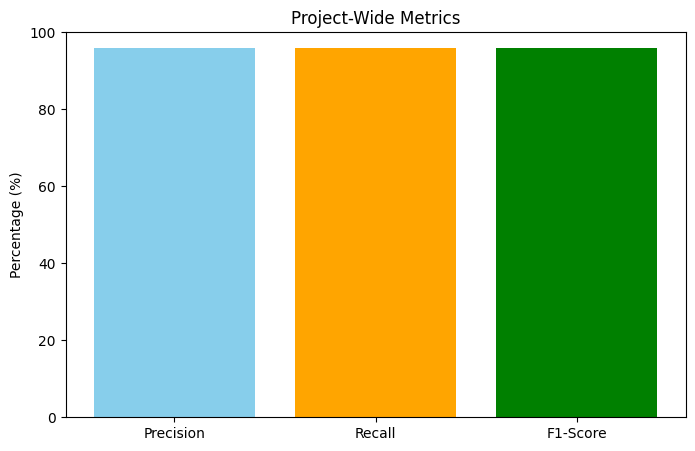

In [29]:
metrics = [precision_avg, recall_avg, f1_avg]
metrics_names = ['Precision', 'Recall', 'F1-Score']

plt.figure(figsize=(8,5))
plt.bar(metrics_names, [m*100 for m in metrics], color=['skyblue','orange','green'])
plt.ylabel("Percentage (%)")
plt.title("Project-Wide Metrics")
plt.ylim(0, 100)
plt.show()

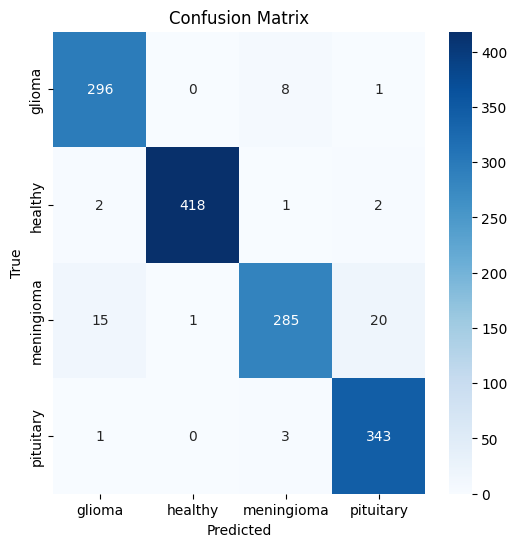

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(6,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

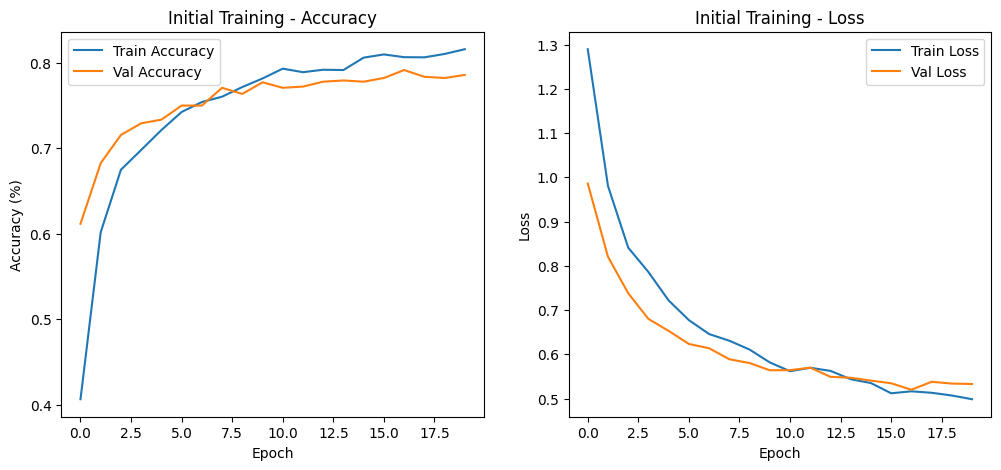

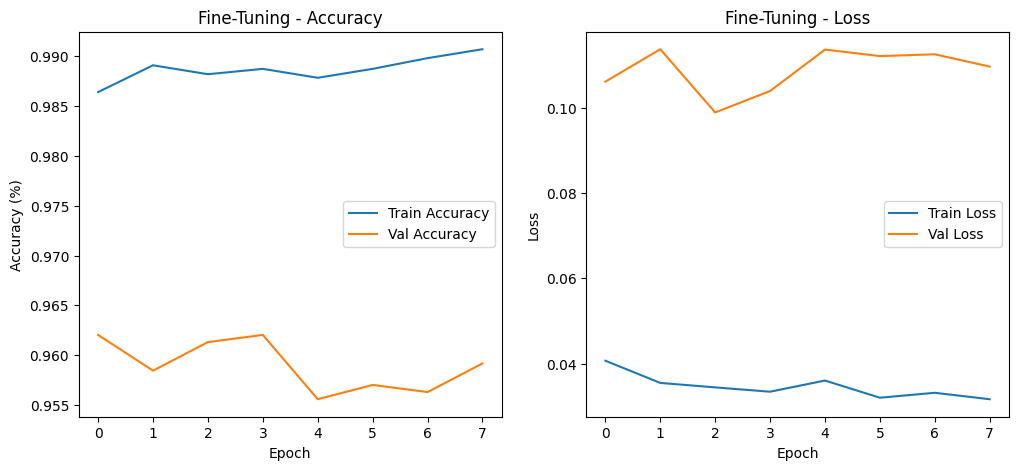

In [31]:
def plot_history(history, title="Training History"):
    plt.figure(figsize=(12,5))
    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Val Accuracy')
    plt.ylabel("Accuracy (%)")
    plt.xlabel("Epoch")
    plt.legend()
    plt.title(f'{title} - Accuracy')
    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.title(f'{title} - Loss')
    plt.show()

plot_history(history, title="Initial Training")
plot_history(history_finetune, title="Fine-Tuning")